In [1]:
import os
import time
import math
import pickle
from contextlib import nullcontext

import numpy as np
import torch
from torch.nn.parallel import DistributedDataParallel as DDP
from torch.distributed import init_process_group, destroy_process_group

from model import (
    GPTConfig,
    GPT,
    CausalSelfAttention,
    SplitCausalSelfAttentionVariableNumHeadsIndependent,
)

from matplotlib import pyplot as plt
from typing import Optional

In [2]:
device_type = "cuda" if torch.cuda.is_available() else "cpu"
device = torch.device(device_type)
dtype = "bfloat16"
dataset = "openwebtext"

In [3]:
batch_size = 16
checkpoints_dir = "out"

In [4]:
def load_checkpoint(checkpoint_iter: int, output_attentions: bool = False):
    model_args = {}
    ckpt_path = os.path.join(checkpoints_dir, f"ckpt_{checkpoint_iter}.pt")
    checkpoint = torch.load(ckpt_path, map_location=device, weights_only=False)
    checkpoint_model_args = checkpoint["model_args"]
    # force these config attributes to be equal otherwise we can't even resume training
    # the rest of the attributes (e.g. dropout) can stay as desired from command line
    for k in ["n_layer", "n_head", "n_embd", "block_size", "bias", "vocab_size"]:
        model_args[k] = checkpoint_model_args[k]
    # create the model
    gptconf = GPTConfig(**model_args)
    gptconf.output_attentions = output_attentions  # update config if needed
    model = GPT(gptconf)
    state_dict = checkpoint["model"]
    # fix the keys of the state dictionary :(
    # honestly no idea how checkpoints sometimes get this prefix, have to debug more
    unwanted_prefix = "_orig_mod."
    for k, v in list(state_dict.items()):
        if k.startswith(unwanted_prefix):
            state_dict[k[len(unwanted_prefix) :]] = state_dict.pop(k)
    model.load_state_dict(state_dict, strict=False)
    return model, gptconf

In [5]:
ptdtype = {
    "float32": torch.float32,
    "bfloat16": torch.bfloat16,
    "float16": torch.float16,
}[dtype]
ctx = (
    nullcontext()
    if device_type == "cpu"
    else torch.amp.autocast(device_type=device_type, dtype=ptdtype)
)

# poor man's data loader
data_dir = os.path.join("data", dataset)


def get_batch(split, batch_size, block_size):
    # We recreate np.memmap every batch to avoid a memory leak, as per
    # https://stackoverflow.com/questions/45132940/numpy-memmap-memory-usage-want-to-iterate-once/61472122#61472122
    if split == "train":
        data = np.memmap(os.path.join(data_dir, "train.bin"), dtype=np.uint16, mode="r")
    else:
        data = np.memmap(os.path.join(data_dir, "val.bin"), dtype=np.uint16, mode="r")
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack(
        [torch.from_numpy((data[i : i + block_size]).astype(np.int64)) for i in ix]
    )
    y = torch.stack(
        [
            torch.from_numpy((data[i + 1 : i + 1 + block_size]).astype(np.int64))
            for i in ix
        ]
    )
    if device_type == "cuda":
        # pin arrays x,y, which allows us to move them to GPU asynchronously (non_blocking=True)
        x, y = x.pin_memory().to(device, non_blocking=True), y.pin_memory().to(
            device, non_blocking=True
        )
    else:
        x, y = x.to(device), y.to(device)
    return x, y

In [6]:
early_model, model_cfg = load_checkpoint(100, True)
late_model, _ = load_checkpoint(3900, True)
mid_model, _ = load_checkpoint(1000, True)

number of parameters: 16.03M
number of parameters: 16.03M
number of parameters: 16.03M


In [55]:
# helps estimate an arbitrarily accurate loss over either split using many batches
@torch.no_grad()
def estimate_loss(model, eval_iters: int = 100):
    out = {}
    model.eval()
    for split in ["train", "val"]:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split, batch_size, model_cfg.block_size)
            with ctx:
                if model_cfg.output_attentions:
                    logits, loss, attn_weights = model(X, Y)
                else:
                    logits, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean()
    model.train()
    return out

In [56]:
estimate_loss(early_model, 10)

{'train': tensor(7.3872), 'val': tensor(7.3566)}

In [57]:
estimate_loss(mid_model, 10)

{'train': tensor(4.8360), 'val': tensor(4.8870)}

In [58]:
estimate_loss(late_model, 10)

{'train': tensor(4.1089), 'val': tensor(4.1411)}

In [7]:
X, Y = get_batch("val", 16, model_cfg.block_size)
with ctx:
    attn_weights_list = []
    for model in [early_model, mid_model, late_model]:
        _, _, attn_weights = model(X, Y)
        attn_weights_list.append(attn_weights)

In [43]:
attn_weights[0].shape

torch.Size([16, 4, 512, 512])

In [60]:
def show_attn(
    attn_map: np.ndarray,
    token_labels: Optional[list[str]] = None,
    log_scale: bool = False,
) -> None:
    """
    Visualizes an attention map with token labels.

    Parameters:
        attn_map (np.ndarray): The attention map to visualize. It is expected to be a 2D array.
        token_labels (list[str]): A list of token labels corresponding to the attention map.
        log_scale (bool, optional): If True, applies a logarithmic scale to the attention map values. Defaults to False.

    Returns:
        None
    """
    _, ax = plt.subplots(figsize=(8, 8))

    # mask for plotting the bad color for padding tokens (upper triangular part)
    attn_map = np.ma.masked_where(attn_map == 0, attn_map)

    cmap = plt.cm.coolwarm
    cmap.set_bad(color="grey")
    ax.matshow(np.log(attn_map) if log_scale else attn_map, cmap=cmap)

    ax.xaxis.set_label_position("bottom")  # Move x-axis label to the bottom
    ax.xaxis.tick_bottom()  # Ensure ticks are on the bottom
    if token_labels is not None:
        _ = ax.set_xticks(
            range(len(token_labels)),
            token_labels,
            fontsize=9,
            rotation=90,
        )
        _ = ax.set_yticks(
            range(len(token_labels)),
            token_labels,
            fontsize=9,
        )
    ax.set_ylabel("Query token", fontsize=12)
    ax.set_xlabel("Key token", fontsize=12)

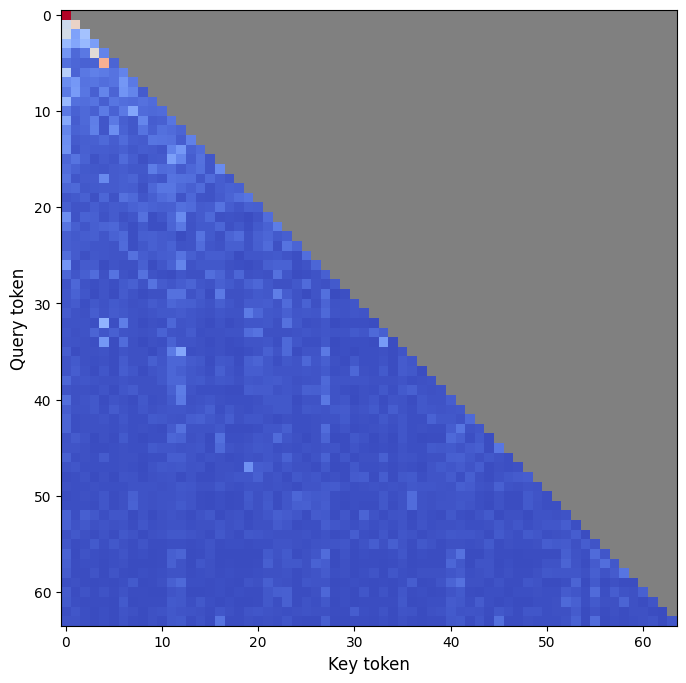

In [78]:
show_attn(attn_weights_list[1][0][0, 3, :64, :64])

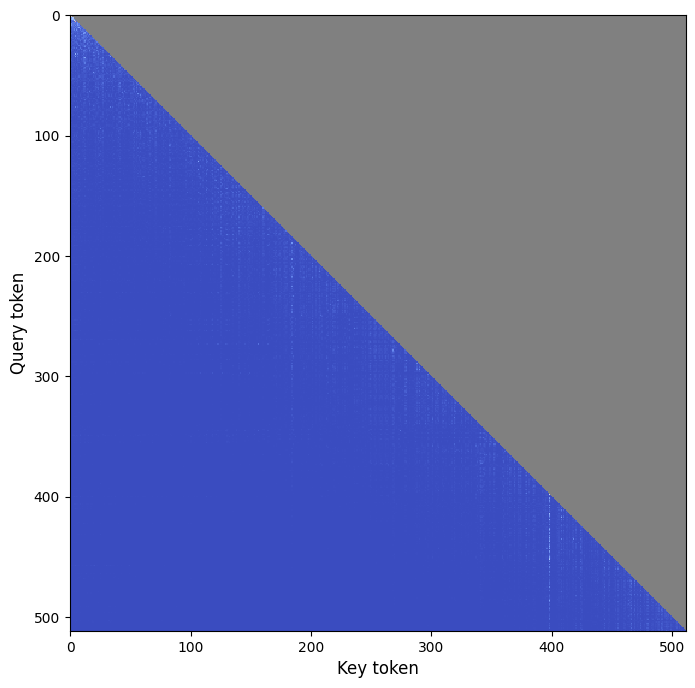

In [92]:
show_attn(attn_weights_list[1][0][0, 3, :, :])

In [ ]:
# early model.
attn_weights_list[0][0][0, 0, :4, :4]

tensor([[1.0000, 0.0000, 0.0000, 0.0000],
        [0.4351, 0.5649, 0.0000, 0.0000],
        [0.2747, 0.3368, 0.3885, 0.0000],
        [0.1842, 0.2439, 0.3251, 0.2468]])

In [8]:
attn_map1 = attn_weights_list[1][2][0, 0]
attn_map2 = attn_weights_list[1][2][0, 2]

In [135]:
m = torch.tril(torch.ones(512, 512))

In [125]:
attn_map[m.bool()]

tensor([1.0000, 0.4351, 0.5649, 0.2747, 0.3368, 0.3885, 0.1842, 0.2439, 0.3251,
        0.2468])

In [126]:
import torch.nn.functional as F

In [146]:
F.cosine_similarity(attn_map1[m.bool()], attn_map2[m.bool()], dim=0)

tensor(0.6974)

In [ ]:
attn_map @ attn_map.T

tensor([[1.0000, 0.4351, 0.2747, 0.1842],
        [0.4351, 0.5084, 0.3098, 0.2179],
        [0.2747, 0.3098, 0.3398, 0.2591],
        [0.1842, 0.2179, 0.2591, 0.2600]])

In [9]:
def biased_hsic(gram1, gram2):
    """
    Computes the Hilbert-Schmidt Independence Criterion (HSIC) between two attention maps.
    """

    h = (
        torch.eye(gram1.shape[0])
        - torch.ones(gram1.shape[0], gram1.shape[0]) / gram1.shape[0]
    )  # centering matrix

    # compute the HSIC value
    hsic_value = torch.trace(gram1 @ h @ gram2 @ h) / ((gram1.shape[0] - 1) ** 2)
    return hsic_value


def unbiased_hsic(gram1, gram2):
    gram1_copy = gram1.clone()
    gram2_copy = gram2.clone()

    gram1_copy.fill_diagonal_(0)  # zero out the diagonal
    gram2_copy.fill_diagonal_(0)  # zero out the diagonal
    n = gram1_copy.shape[0]

    first_term = torch.trace(gram1_copy @ gram2_copy)
    second_term = (gram1_copy.sum() * gram2_copy.sum()) / ((n - 1) * (n - 2))
    third_term = (gram1_copy @ gram2_copy).sum() * 2 / (n - 2)

    return (first_term + second_term - third_term) / (n * (n - 3))


def cka(
    attn1: torch.Tensor | list[torch.Tensor],
    attn2: torch.Tensor | list[torch.Tensor],
    hsic_fn: callable,
):
    """
    Computes the Centered Kernel Alignment (CKA) between two attention maps.
    """
    if isinstance(attn1, list) and isinstance(attn2, list):
        assert len(attn1) == len(
            attn2
        ), "Both attention map lists must have the same length."
    else:
        attn1 = [attn1]
        attn2 = [attn2]

    hsic_kl = hsic_kk = hsic_ll = 0
    for a1, a2 in zip(attn1, attn2):
        gram1 = a1 @ a1.T  # compute the Gram matrix
        gram2 = a2 @ a2.T  # compute the Gram matrix

        hsic_kl += hsic_fn(gram1, gram2) / len(attn1)
        hsic_kk += hsic_fn(gram1, gram1) / len(attn1)
        hsic_ll += hsic_fn(gram2, gram2) / len(attn1)

    return (hsic_kl / torch.sqrt(hsic_kk * hsic_ll)).item()

In [220]:
cka(attn_map1, attn_map2, unbiased_hsic)

0.6742067933082581

In [221]:
cka(attn_map1, attn_map2, biased_hsic)

0.7463142275810242

In [ ]:
def test_hsic_implementations(n=100):
    # Create perfectly correlated data
    x = torch.randn(n, 10)
    y = x.clone()  # Perfect correlation

    # Create kernel matrices
    gram_x = x @ x.T
    gram_y = y @ y.T

    biased_c = biased_hsic(gram_x, gram_y)
    unbiased_c = unbiased_hsic(gram_x, gram_y)

    # Create uncorrelated data
    z = torch.randn(n, 10)
    gram_z = z @ z.T

    biased_uc = biased_hsic(gram_x, gram_z)
    unbiased_uc = unbiased_hsic(gram_x, gram_z)

    return biased_c, unbiased_c, biased_uc, unbiased_uc


test_hsic_implementations()

(tensor(12.9320), tensor(11.6626), tensor(1.1918), tensor(0.1371))

In [ ]:
n = [10**i for i in range(2, 6)]
hsic_biased_c = []
hsic_unbiased_c = []
hsic_biased_uc = []
hsic_unbiased_uc = []
for i in n:
    biased_c, unbiased_c, biased_uc, unbiased_uc = test_hsic_implementations(i)
    hsic_biased_c.append(biased_c)
    hsic_unbiased_c.append(unbiased_c)
    hsic_biased_uc.append(biased_uc)
    hsic_unbiased_uc.append(unbiased_uc)

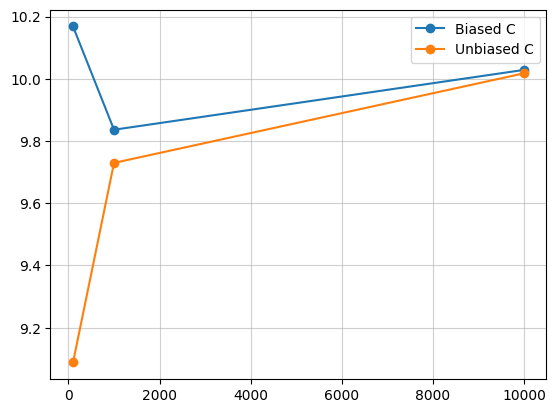

In [ ]:
plt.plot(n, hsic_biased_c, label="Biased C", marker="o")
plt.plot(n, hsic_unbiased_c, label="Unbiased C", marker="o")
plt.grid(alpha=0.6)
plt.legend()
plt.show()

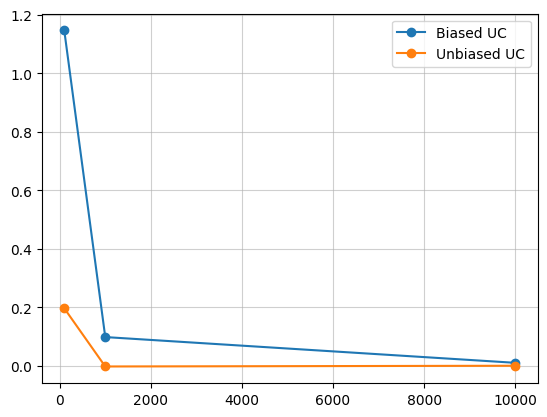

In [ ]:
plt.plot(n, hsic_biased_uc, label="Biased UC", marker="o")
plt.plot(n, hsic_unbiased_uc, label="Unbiased UC", marker="o")
plt.grid(alpha=0.6)
plt.legend()
plt.show()

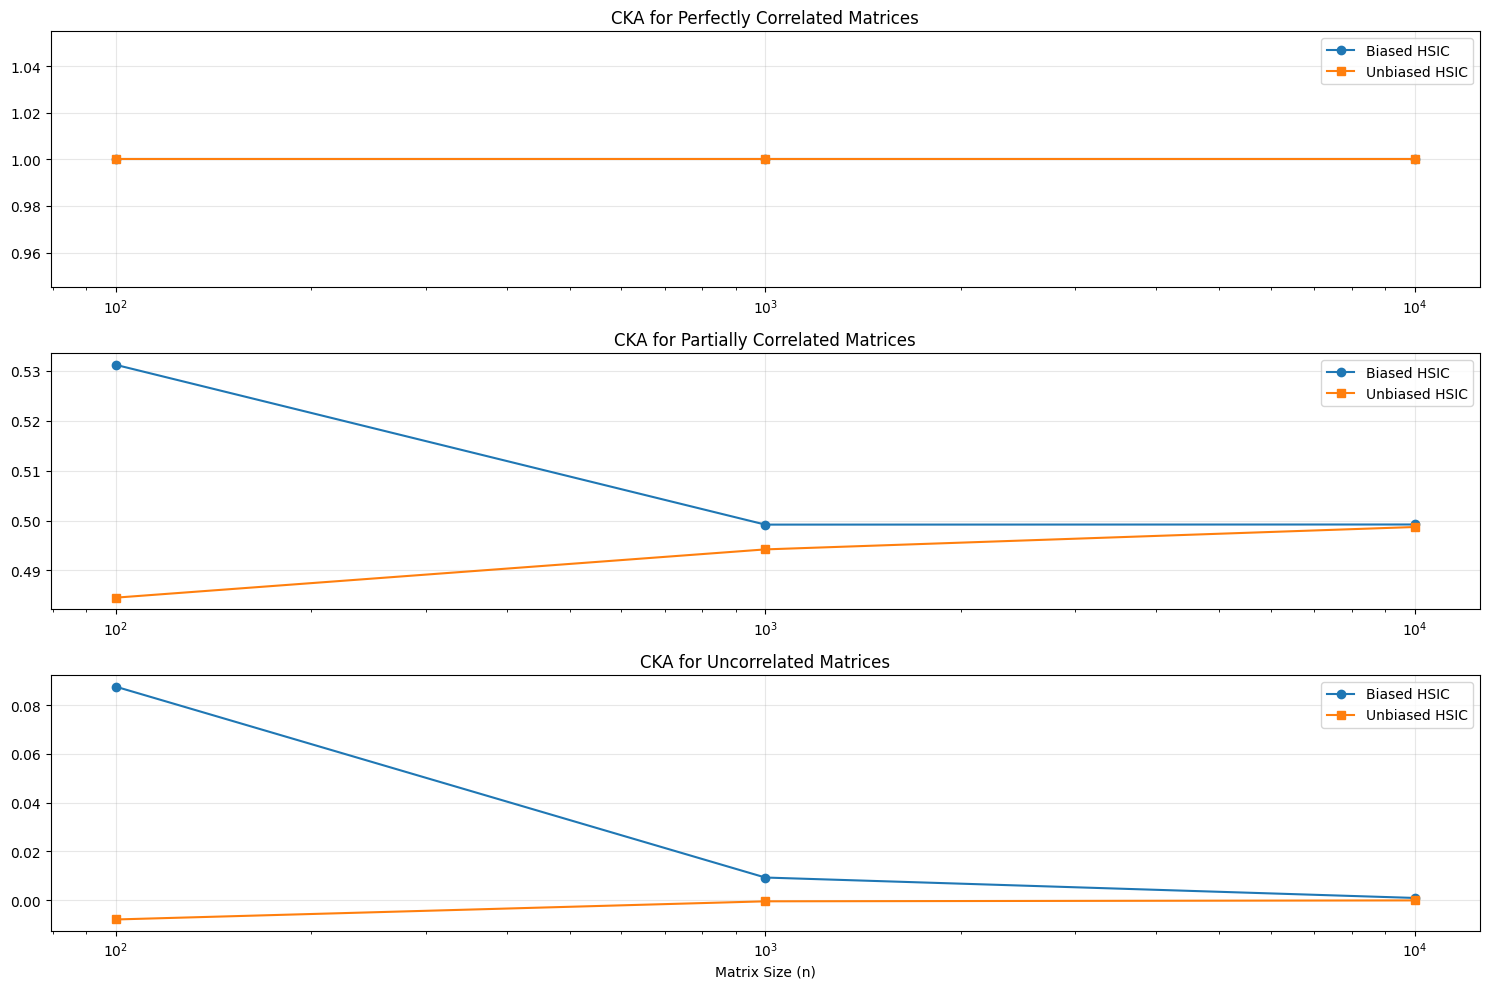

In [ ]:
def test_cka_implementations(n=100, d=10):
    # Create perfectly correlated matrices
    x = torch.randn(n, d)
    y = x.clone()  # Perfect correlation

    # Create partially correlated matrices
    correlation = 0.5
    y_partial = x * correlation + torch.randn(n, d) * (1 - correlation)

    # Create uncorrelated matrices
    z = torch.randn(n, d)

    # Calculate CKA for each correlation level with both HSIC implementations
    results = {}

    # Perfect correlation
    results["perfect_biased"] = cka(x, y, biased_hsic)
    results["perfect_unbiased"] = cka(x, y, unbiased_hsic)

    # Partial correlation
    results["partial_biased"] = cka(x, y_partial, biased_hsic)
    results["partial_unbiased"] = cka(x, y_partial, unbiased_hsic)

    # No correlation
    results["uncorr_biased"] = cka(x, z, biased_hsic)
    results["uncorr_unbiased"] = cka(x, z, unbiased_hsic)

    return results


# Test CKA with different data sizes
n_values = [10**i for i in range(2, 5)]
results = {
    "perfect_biased": [],
    "perfect_unbiased": [],
    "partial_biased": [],
    "partial_unbiased": [],
    "uncorr_biased": [],
    "uncorr_unbiased": [],
}

for n in n_values:
    test_results = test_cka_implementations(n=n)
    for key in results.keys():
        results[key].append(test_results[key])

# Plot results
plt.figure(figsize=(15, 10))

# Perfect correlation
plt.subplot(3, 1, 1)
plt.plot(n_values, results["perfect_biased"], label="Biased HSIC", marker="o")
plt.plot(n_values, results["perfect_unbiased"], label="Unbiased HSIC", marker="s")
plt.xscale("log")
plt.title("CKA for Perfectly Correlated Matrices")
plt.grid(alpha=0.3)
plt.legend()

# Partial correlation
plt.subplot(3, 1, 2)
plt.plot(n_values, results["partial_biased"], label="Biased HSIC", marker="o")
plt.plot(n_values, results["partial_unbiased"], label="Unbiased HSIC", marker="s")
plt.xscale("log")
plt.title("CKA for Partially Correlated Matrices")
plt.grid(alpha=0.3)
plt.legend()

# No correlation
plt.subplot(3, 1, 3)
plt.plot(n_values, results["uncorr_biased"], label="Biased HSIC", marker="o")
plt.plot(n_values, results["uncorr_unbiased"], label="Unbiased HSIC", marker="s")
plt.xscale("log")
plt.title("CKA for Uncorrelated Matrices")
plt.xlabel("Matrix Size (n)")
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()